In [1]:
import torch
import os
import random

from utils import data_utils, cbm_utils, plots
import json
import numpy as np
import colors

import cbm

In [2]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/1_Dataset_filtered_sparse_cub_cbm_2026_03_05_18_16"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)
cls_file = data_utils.LABEL_FILES[dataset]

In [3]:
d_val = dataset + "_val"
print(args["clip_name"], args["backbone"], args["feature_layer"], d_val,  args["concept_set"], "avg", args["activation_dir"])
val_target_save_name, val_clip_save_name, text_save_name =  cbm_utils.get_save_names(args["clip_name"], args["backbone"],
                                            args["feature_layer"], d_val  , args["concept_set"], "avg", args["activation_dir"])
print("output: ", val_target_save_name, val_clip_save_name, text_save_name)

ViT-B/16 resnet18_cub features.final_pool cub_val data/concept_sets/cub_filtered_Attributes.txt avg saved_activations
output:  saved_activations/cub_val_resnet18_cub_features.final_pool.pt saved_activations/cub_val_clip_ViT-B16.pt saved_activations/cub_filtered_Attributes_ViT-B16.pt


In [4]:
#Read class file
with open(cls_file, "r") as f:
    classes = f.read().split("\n")
#Load concepts text
with open(args["concept_set"], "r") as f:
    concepts = f.read().split("\n")
#load val images
val_pil_data = data_utils.get_data(d_val)

In [5]:
#Calculate val_clip_features -> concept layer target
val_image_features = torch.load(val_clip_save_name, map_location="cpu").float()
val_image_features /= torch.norm(val_image_features, dim=1, keepdim=True)

text_features = torch.load(text_save_name, map_location="cpu").float()
text_features /= torch.norm(text_features, dim=1, keepdim=True)

val_clip_features = val_image_features @ text_features.T

In [6]:
def test_cos_similarity_cubed_single(clip_feats, use_cubed=True):
    """
    Substract mean from each vector, then raises to third power and compares cos similarity
    Does not modify any tensors in place
    Only compares first neuron to first concept etc.
    """

    clip_feats = clip_feats.float()
    clip_feats = clip_feats - torch.mean(clip_feats, dim=0, keepdim=True)
    #target_feats = target_feats - torch.mean(target_feats, dim=0, keepdim=True)

    if use_cubed: clip_feats = clip_feats**3
    #target_feats = target_feats**3

    clip_feats = clip_feats/torch.norm(clip_feats, p=2, dim=0, keepdim=True)
    #target_feats = target_feats/torch.norm(target_feats, p=2, dim=0, keepdim=True)

    #similarities = torch.sum(target_feats*clip_feats, dim=0)
    return clip_feats

In [7]:
#get top ten concepts for both (Name and concept value)
def get_topk_concepts(similarities, concepts, top_k=10, best=True):
    top_k_indices = torch.topk(similarities, top_k, largest=best).indices
    return np.array([[idx.item(), concepts[idx.item()], similarities[idx].item()] for idx in top_k_indices])


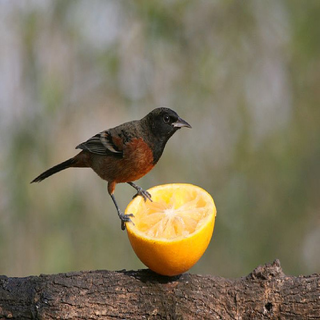

True


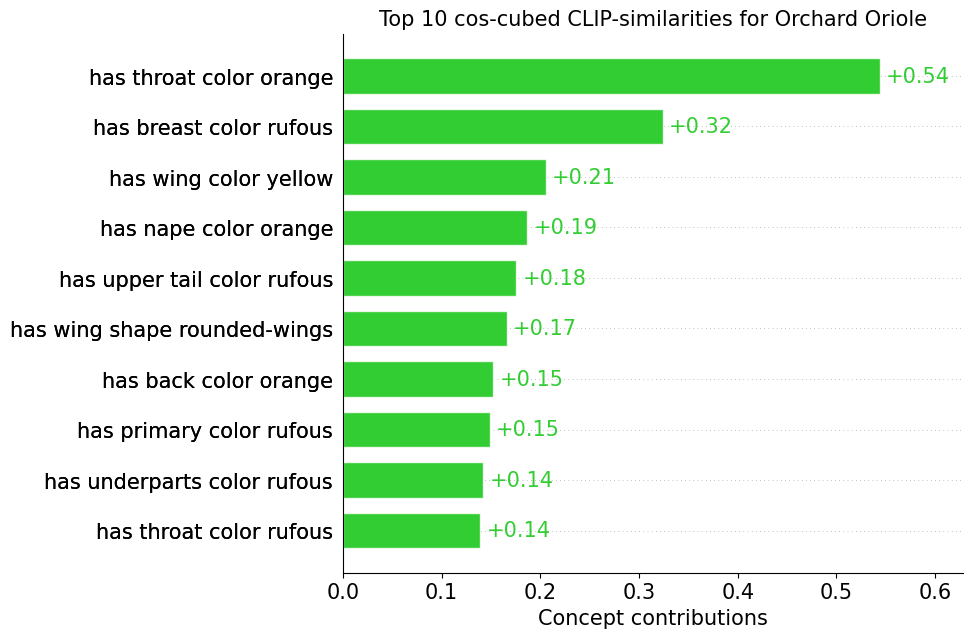

In [17]:
image_id = 2747     #2760 rufous,
do_print = True
val_clip_sim = test_cos_similarity_cubed_single(val_clip_features[image_id], False)
val_clip_sim_cubed = test_cos_similarity_cubed_single(val_clip_features[image_id], True)


image, label = val_pil_data[image_id]
display(image.resize([320,320]))
cub_bird_species_name = classes[int(label)]

top_concepts = get_topk_concepts(val_clip_sim_cubed, concepts, 10, True)
values = np.array(top_concepts[:,2], dtype=float)
feature_names = np.array(top_concepts[:,1])
max_display = 10
title = f"Top {max_display} cos-cubed CLIP-similarities for {cub_bird_species_name}"
plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=15, do_print=do_print, positive_bar_color="limegreen")

In [18]:
##### Section for saving image and plot as a single image ####
if do_print:
    from PIL import Image

    img = image
    plot = Image.open("test\\feature_importances.png")

    # Match heights
    h = max(img.height, plot.height)

    # Resize keeping aspect ratio
    img_resized = img.resize((int(img.width * h / img.height), h))
    plot_resized = plot.resize((int(plot.width * h / plot.height), h))

    # Create combined canvas
    combined_w = img_resized.width + plot_resized.width
    combined = Image.new("RGB", (combined_w, h), (255, 255, 255))

    # Paste side-by-side
    combined.paste(img_resized, (0, 0))
    combined.paste(plot_resized, (img_resized.width, 0))

    combined.save("test\\features_CLIP_combined.png")